# RL policy evaluation
**Responsible:** _(Aldo Patrone)_

Both learned policies are evaluated in the same paper-faithful GymAllocationEnv they are trained in (state 2R+A, (r,a) action space with masking, cycle-time reward plus a small postpone cost), against baselines that make the same (r,a) decisions: random, round-robin, shortest-queue, most-experienced. MaskablePPO uses the global action space, while the lightweight numpy REINFORCE keeps its per-candidate policy and acts through the same decision interface, so both share identical dynamics and reward and are directly comparable.

The postpone cost matters: without it the high-variance REINFORCE degenerates into a wait-only policy that completes no cases. The baselines are this environment's own implementations: shortest-queue selects the least-loaded eligible resource and most-experienced the highest-skill one. The cell below is the head-to-head at w_fair=1, and the next cell is the fairness-weight sensitivity over w_fair in {0,1,5}. All numbers come from scripts/train_reinforce_gym.py (results/wfair_sensitivity.csv).

                   cycle_time_h  load_gini
method                                    
random                     4.88      0.267
round-robin                4.83      0.263
shortest-queue             4.75      0.164
most-experienced           4.60      0.397
REINFORCE                  4.76      0.407
PPO (MaskablePPO)          5.14      0.378
saved ../results/allocation_sim_comparison.png


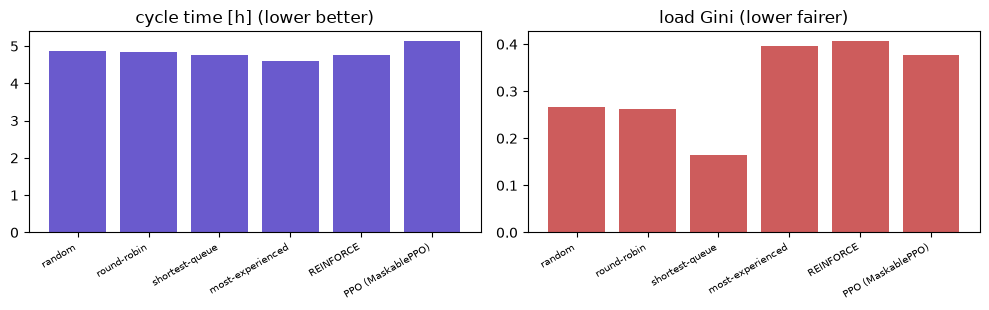

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Unified comparison in the paper-faithful GymAllocationEnv (identical dynamics and reward for
# baselines, REINFORCE and PPO). w_fair=1 slice; produced by scripts/train_reinforce_gym.py.
sens = pd.read_csv('../results/wfair_sensitivity.csv')
w1 = sens[sens.w_fair == 1.0].set_index('method')
order = ['random', 'round-robin', 'shortest-queue', 'most-experienced', 'REINFORCE', 'PPO (MaskablePPO)']
print(w1.reindex(order)[['cycle_time_h', 'load_gini']].to_string())
if w1['cycle_time_h'].isna().any():
    print('\nNote: a NaN cycle time means the policy completed no cases (degenerate); its Gini then '
          'does not reflect fairness.')

# bar chart over the methods with a valid cycle time
valid = w1.reindex([m for m in order if pd.notna(w1.loc[m, 'cycle_time_h'])]).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].bar(valid['method'], valid['cycle_time_h'], color='slateblue')
axes[0].set_title('cycle time [h] (lower better)')
axes[1].bar(valid['method'], valid['load_gini'], color='indianred')
axes[1].set_title('load Gini (lower fairer)')
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
    for lbl in ax.get_xticklabels():
        lbl.set_ha('right'); lbl.set_fontsize(7)
fig.tight_layout(); fig.savefig('../results/allocation_sim_comparison.png', dpi=120)
print('saved ../results/allocation_sim_comparison.png')

## RL policy: result and fairness-weight sensitivity
**Responsible:** _(Aldo Patrone)_

Honest finding: neither learned policy beats the simple heuristics. Cycle times cluster ~4.6 to 5.1 h across all methods (within run-to-run variance), so allocation barely moves the objective. On fairness, shortest-queue is decisively best (Gini 0.164), while both learned policies are among the least fair (REINFORCE 0.407, PPO 0.378, like most-experienced 0.397) because they concentrate work on few resources.

The sensitivity below shows no clean w_fair trend for either learned method (their Gini wanders in a noisy 0.35 to 0.42 band and never reaches shortest-queue). That noise is expected: the arrival stream is not reseeded per episode, so absolute numbers carry a few-percent run-to-run variance, an honest limitation of this standalone environment.

Integrated deployment: the policy also plugs into SimulationEngineCore via optimization.ppo_agent.PPOAllocation (per-task reduction). The group-wide comparison of the other allocation methods is task F (3.6.7), which runs in the integrated fixed-replay engine on a different scale and is therefore not directly comparable to these numbers.

                  cycle_time_h             load_gini              
w_fair                     0.0   1.0   5.0       0.0    1.0    5.0
method                                                            
PPO (MaskablePPO)         4.77  5.14  4.86     0.419  0.378  0.396
REINFORCE                 5.02  4.76  4.90     0.366  0.407  0.352
most-experienced          4.60  4.60  4.60     0.397  0.397  0.397
random                    4.88  4.88  4.88     0.267  0.267  0.267
round-robin               4.83  4.83  4.83     0.263  0.263  0.263
shortest-queue            4.75  4.75  4.75     0.164  0.164  0.164


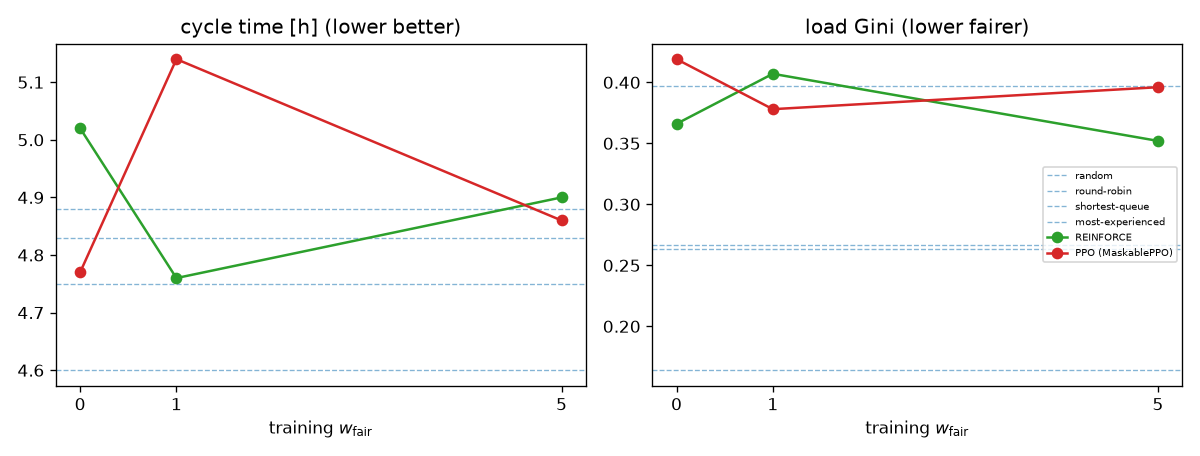

In [2]:
import pandas as pd
from IPython.display import Image, display

# Fairness-weight sensitivity over w_fair in {0,1,5}. Baselines are reward-independent (flat lines).
# Produced by scripts/train_reinforce_gym.py (annotated figure in results/).
sens = pd.read_csv('../results/wfair_sensitivity.csv')
print(sens.pivot(index='method', columns='w_fair', values=['cycle_time_h', 'load_gini']).to_string())
display(Image('../results/wfair_sensitivity.png'))